In [11]:
import os
import json
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI


# =========================
# Config ollama
# =========================
client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)

MODEL_NAME = "mistral:7b"


# =========================
# Filtres et bools
# =========================
def is_bool_series(s: pd.Series) -> bool:
    if pd.api.types.is_bool_dtype(s):
        return True
    if s.dtype == "object":
        vals = set(s.dropna().unique().tolist())
        return vals.issubset({True, False, "True", "False", "true", "false", 0, 1, "0", "1"})
    return False


def coerce_bool_value(v: Any) -> Optional[bool]:
    if v is None:
        return None
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)) and v in (0, 1):
        return bool(int(v))
    if isinstance(v, str):
        t = v.strip().lower()
        if t in ("true", "vrai", "1", "yes", "y"):
            return True
        if t in ("false", "faux", "0", "no", "n"):
            return False
    return None


def safe_apply_filters(df: pd.DataFrame, filters: List[Dict[str, Any]]) -> pd.DataFrame:
    if not filters:
        return df

    out = df.copy()
    for f in filters:
        if not isinstance(f, dict):
            print(f"[filter] ignore: filtre invalide {f}")
            continue

        col = f.get("column")
        val = f.get("value")
        op = f.get("op", "==")

        if isinstance(col, list):
            col = col[0] if col else None
        if col not in out.columns:
            print(f"[filter] ignore: colonne inconnue {col}")
            continue

        s = out[col]

        # Bool : on force == True/False si possible
        if is_bool_series(s):
            b = coerce_bool_value(val)
            if b is None:
                b = True
            out = out[s.astype(str).str.lower().isin([str(b).lower()])]
            continue

        # Vérif valeur pour colonnes string (éviter df vide inutile)
        if val is not None:
            if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
                uniques = set(s.dropna().astype(str).unique().tolist())
                if str(val) not in uniques and op in ("==", None):
                    print(f"[filter] ignore: la valeur '{val}' n'est pas dans les valeurs uniques de {col}")
                    continue

        # Application filtre
        if op == "==" or op is None:
            out = out[out[col] == val]
        elif op == "!=":
            out = out[out[col] != val]
        elif op in (">", ">=", "<", "<="):
            sn = pd.to_numeric(out[col], errors="coerce")
            vn = pd.to_numeric(pd.Series([val]), errors="coerce").iloc[0]
            if pd.isna(vn):
                print(f"[filter] ignore: valeur non numérique pour opé numérique: {val}")
                continue
            if op == ">":
                out = out[sn > vn]
            elif op == ">=":
                out = out[sn >= vn]
            elif op == "<":
                out = out[sn < vn]
            elif op == "<=":
                out = out[sn <= vn]
        elif op == "contains":
            out = out[out[col].astype(str).str.contains(str(val), na=False)]
        elif op == "in" and isinstance(val, list):
            out = out[out[col].isin(val)]
        else:
            print(f"[filter] ignore: opération non supportée {op}")
            continue

    return out


# =========================
# Chargement JSON -> DataFrame
# =========================
def flatten_json(obj, parent="", sep="_"):
    items = {}
    for k, v in obj.items():
        new_key = f"{parent}{sep}{k}" if parent else k
        if isinstance(v, dict):
            items.update(flatten_json(v, new_key, sep=sep))
        else:
            items[new_key] = v
    return items


def load_df(path: str, sample_rows: int = 5000):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= sample_rows:
                break
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append(flatten_json(obj))

    df = pd.DataFrame(rows)
    df.columns = df.columns.str.strip()
    return df


# =========================
# LLM intent extraction
# =========================
INTENT_SYSTEM = """
You are a data visualization intent extractor.

Return ONLY valid JSON:

{
  "intent": "count" | "scatter" | "line" | "distribution" | "trend" | "time_series" | "histogram" | "table" | "metric",
  "chart": "auto" | "bar" | "scatter" | "line" | "area" | "pie" | "histogram" | "table" | "metric",
  "aggregation": "count" | "sum" | "mean" | "avg" | "min" | "max" | "nunique" | null,
  "group_by": string | [string] | null,
  "x": string | [string] | null,
  "y": string | [string] | null,
  "top_n": number | null,
  "bins": number | null,
  "filter": [{"column": string, "value": any, "op": "==" | "!=" | ">" | ">=" | "<" | "<=" | "contains" | "in"}] | []
}

Rules:
- Use ONLY column names provided in SCHEMA.
- If user asks for "nombre", "combien", "count", "répartition", use aggregation="count".
- If user asks for "moyenne", use aggregation="mean".
- If user asks for "somme"/"total", use aggregation="sum".
- If user asks for "minimum"/"maximum", use aggregation="min"/"max".
- If user asks "nombre de valeurs uniques", use aggregation="nunique".
- Prefer chart="line" for temporal evolution / trend.
- Prefer chart="histogram" for distribution of ONE numeric variable.
- Return JSON only.
"""


def extract_intent(prompt: str, df: pd.DataFrame) -> Dict[str, Any]:
    schema = list(df.columns)

    msg = f"""
SCHEMA:
{schema}

USER_PROMPT:
{prompt}
"""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": INTENT_SYSTEM},
            {"role": "user", "content": msg},
        ],
        temperature=0.1
    )

    content = response.choices[0].message.content.strip()
    content = re.sub(r"^```(?:json)?", "", content).strip()
    content = re.sub(r"```$", "", content).strip()

    return json.loads(content)


# =========================
# Helpers robustesse / agrégation
# =========================
def normalize_agg_name(agg: Optional[str]) -> Optional[str]:
    if agg is None:
        return None
    agg = str(agg).lower().strip()
    if agg == "avg":
        return "mean"
    return agg


def maybe_to_datetime_series(s: pd.Series) -> pd.Series:
    try:
        s_dt = pd.to_datetime(s, errors="coerce")
        # on convertit seulement si on a une proportion correcte de dates parsées
        if len(s) > 0 and s_dt.notna().sum() >= max(1, int(0.5 * len(s))):
            return s_dt
    except Exception:
        pass
    return s


def aggregate_series(s: pd.Series, agg: str) -> Any:
    agg = normalize_agg_name(agg)
    if agg == "count":
        return int(s.shape[0])
    if agg == "sum":
        sn = pd.to_numeric(s, errors="coerce")
        return sn.sum()
    if agg == "mean":
        sn = pd.to_numeric(s, errors="coerce")
        return sn.mean()
    if agg == "min":
        sn = pd.to_numeric(s, errors="coerce")
        return sn.min()
    if agg == "max":
        sn = pd.to_numeric(s, errors="coerce")
        return sn.max()
    if agg == "nunique":
        return int(s.nunique(dropna=True))
    raise ValueError(f"Agrégation non supportée: {agg}")


def groupby_aggregate(df: pd.DataFrame, group_by: str, y: Optional[str], agg: str) -> pd.DataFrame:
    agg = normalize_agg_name(agg) or "count"

    if group_by not in df.columns:
        raise ValueError(f"Colonne group_by inconnue: {group_by}")

    if agg == "count":
        out = df[group_by].value_counts(dropna=False).reset_index()
        out.columns = [group_by, "value"]
        return out

    if y is None or y not in df.columns:
        raise ValueError(f"Aggregation '{agg}' nécessite une colonne y valide.")

    if agg in ("sum", "mean", "min", "max"):
        tmp = df[[group_by, y]].copy()
        tmp[y] = pd.to_numeric(tmp[y], errors="coerce")
        tmp = tmp.dropna(subset=[y])
        if tmp.empty:
            return pd.DataFrame(columns=[group_by, "value"])
        grouped = tmp.groupby(group_by, dropna=False)[y].agg(agg).reset_index()
        grouped.columns = [group_by, "value"]
        return grouped

    if agg == "nunique":
        tmp = df[[group_by, y]].copy()
        grouped = tmp.groupby(group_by, dropna=False)[y].nunique(dropna=True).reset_index()
        grouped.columns = [group_by, "value"]
        return grouped

    raise ValueError(f"groupby_aggregate: agg non supportée {agg}")


# =========================
# Intent repair (stabilité / rétrocompatibilité)
# =========================
def _first_if_list(v):
    if isinstance(v, list):
        return v[0] if len(v) > 0 else None
    return v


def _safe_int(v, default=None):
    try:
        return int(v) if v is not None else default
    except Exception:
        return default


def normalize_intent(intent: Dict[str, Any]) -> Dict[str, Any]:
    """Normalisation + anti-crash (LLM imparfait)."""
    out = dict(intent) if isinstance(intent, dict) else {}

    out["chart"] = (out.get("chart") or "auto")
    if isinstance(out["chart"], str):
        out["chart"] = out["chart"].lower()

    if isinstance(out.get("intent"), str):
        out["intent"] = out["intent"].lower()

    out["aggregation"] = normalize_agg_name(out.get("aggregation"))

    # LLM peut renvoyer list au lieu de string
    out["group_by"] = _first_if_list(out.get("group_by"))
    out["x"] = _first_if_list(out.get("x"))
    out["y"] = _first_if_list(out.get("y"))

    out["top_n"] = _safe_int(out.get("top_n"), None)
    out["bins"] = _safe_int(out.get("bins"), None)

    # filters robuste
    filters = out.get("filter")
    if not isinstance(filters, list):
        filters = []
    cleaned_filters = []
    for f in filters:
        if not isinstance(f, dict):
            continue
        col = _first_if_list(f.get("column"))
        op = f.get("op", "==")
        cleaned_filters.append({
            "column": col,
            "value": f.get("value"),
            "op": op
        })
    out["filter"] = cleaned_filters

    return out


In [12]:


def repair_intent_for_engine(intent_n: Dict[str, Any], df: pd.DataFrame, prompt: str = "") -> Dict[str, Any]:
    """
    Répare les cas incohérents pour ne pas casser les prompts qui marchaient avant.
    """
    out = dict(intent_n)
    prompt_l = (prompt or "").lower()

    group_by = out.get("group_by")
    y = out.get("y")
    agg = out.get("aggregation")

    # 1) Colonnes inexistantes -> neutraliser (mieux qu'un crash)
    for key in ("group_by", "x", "y"):
        val = out.get(key)
        if val is not None and val not in df.columns:
            print(f"[intent-repair] {key}='{val}' absent du schema -> None")
            out[key] = None

    group_by = out.get("group_by")
    y = out.get("y")
    agg = out.get("aggregation")

    # 2) Agg non exploitable sans y -> fallback count
    if group_by and agg in ("nunique", "sum", "mean", "min", "max") and not y:
        print(f"[intent-repair] agg='{agg}' sans y avec group_by -> fallback count")
        out["aggregation"] = "count"

    # 3) distribution table nunique sans y -> count
    if (
        out.get("intent") == "distribution"
        and out.get("chart") == "table"
        and out.get("aggregation") == "nunique"
        and group_by
        and not y
    ):
        print("[intent-repair] distribution table nunique sans y -> count")
        out["aggregation"] = "count"

    # 4) histogram sans colonne claire
    if out.get("chart") == "histogram":
        col = out.get("x") or out.get("y")
        if col is None:
            print("[intent-repair] histogram sans x/y -> chart auto")
            out["chart"] = "auto"

    # 5) intent=count mais agg absent
    if out.get("intent") == "count" and out.get("aggregation") is None:
        out["aggregation"] = "count"

    # 6) Heuristique rétrocompat : répartition/distribution => bar par défaut (sauf demande explicite table)
    asks_table_explicitly = any(k in prompt_l for k in ["table", "tabulaire", "tableau"])
    if group_by and (out.get("intent") in ("distribution", "count") or "répartition" in prompt_l or "distribution" in prompt_l):
        if out.get("aggregation") is None:
            out["aggregation"] = "count"

        if out.get("chart") in (None, "auto", "table") and not asks_table_explicitly:
            print("[intent-repair] répartition legacy -> chart='bar'")
            out["chart"] = "bar"

    return out


def extract_intent_safe(prompt: str, df: pd.DataFrame) -> Dict[str, Any]:
    """
    Wrapper stable:
    - extraction LLM
    - normalisation
    - réparation
    """
    raw_intent = extract_intent(prompt, df)
    norm = normalize_intent(raw_intent)
    repaired = repair_intent_for_engine(norm, df, prompt)
    return repaired


# =========================
# Spec de plotting
# =========================
@dataclass
class PlotSpec:
    plot_type: str  # "bar_agg","single_count","scatter","line","area","pie","histogram","metric","table","line_agg","area_xy"
    x: Optional[str] = None
    y: Optional[str] = None
    group_by: Optional[str] = None
    filters: Optional[List[Dict[str, Any]]] = None
    sort_by: Optional[str] = None  # "count", "x", "y", "value"
    sort_ascending: bool = False
    aggregation: Optional[str] = None
    top_n: Optional[int] = None
    bins: Optional[int] = None


# =========================
# Décision de stratégie
# =========================
def build_plot_spec(df: pd.DataFrame, intent: Dict[str, Any]) -> PlotSpec:
    """
    Décide ce qu'il faut tracer (stratégie), sans tracer.
    """
    intent_n = normalize_intent(intent)

    chart = intent_n.get("chart", "auto")
    intent_type = intent_n.get("intent")
    agg = intent_n.get("aggregation")
    group_by = intent_n.get("group_by")
    x = intent_n.get("x")
    y = intent_n.get("y")
    top_n = intent_n.get("top_n")
    bins = intent_n.get("bins")
    filters = intent_n.get("filter") or []

    # fallback agg
    if agg is None and intent_type in ("count", "distribution"):
        agg = "count"
    
    chart_is_explicit = chart not in (None, "", "auto")

    # table explicite
    if chart == "table" or (intent_type == "table" and not chart_is_explicit):
        if group_by and group_by in df.columns:
            return PlotSpec(
                plot_type="table",
                group_by=group_by,
                x=x,
                y=y,
                aggregation=agg or "count",
                filters=filters,
                top_n=top_n,
                sort_by="value",
                sort_ascending=False
            )
        if x and x in df.columns:
            return PlotSpec(
                plot_type="table",
                x=x,
                y=y,
                aggregation=agg,
                filters=filters,
                top_n=top_n
            )

    # metric explicite
    if chart == "metric" or (intent_type == "metric" and not chart_is_explicit):
        return PlotSpec(
            plot_type="metric",
            y=y if y in df.columns else None,
            aggregation=agg or "count",
            filters=filters
        )

    # histogram explicite
    if chart == "histogram" or (intent_type == "histogram" and not chart_is_explicit):
        col = x if x in df.columns else (y if y in df.columns else None)
        if col:
            return PlotSpec(
                plot_type="histogram",
                x=col,
                filters=filters,
                bins=bins or 20,
                sort_ascending=True
            )

    # group_by + agg (coeur "Lens-like")
    if group_by and group_by in df.columns:
        chosen_agg = agg or "count"

        # fallback stabilité: agg non-count sans y => count
        if chosen_agg in ("sum", "mean", "min", "max", "nunique") and (not y or y not in df.columns):
            print(f"[intent-repair] {chosen_agg} sans y exploitable -> count")
            chosen_agg = "count"

        if chart == "pie":
            return PlotSpec(
                plot_type="pie",
                group_by=group_by,
                x=x,
                y=y,
                aggregation=chosen_agg,
                filters=filters,
                top_n=top_n,
                sort_by="value",
                sort_ascending=False
            )

        if chart == "area":
            return PlotSpec(
                plot_type="area",
                group_by=group_by,
                x=x,
                y=y,
                aggregation=chosen_agg,
                filters=filters,
                top_n=top_n,
                sort_by="value",
                sort_ascending=False
            )

        if chart == "line" and y and y in df.columns:
            return PlotSpec(
                plot_type="line_agg",
                group_by=group_by,
                y=y,
                aggregation=chosen_agg,
                filters=filters,
                top_n=top_n,
                sort_by="x",
                sort_ascending=True
            )

        # défaut robuste = bar agrégé
        return PlotSpec(
            plot_type="bar_agg",
            group_by=group_by,
            x=x,  # utilisé pour cas spécial bool count
            y=y,
            aggregation=chosen_agg,
            filters=filters,
            top_n=top_n,
            sort_by="value",
            sort_ascending=False
        )

    # count simple
    if (intent_type == "count") or (agg == "count" and not group_by and not x and not y):
        return PlotSpec(
            plot_type="single_count",
            aggregation="count",
            filters=filters
        )

    # metric implicite si agg + y sans group_by
    if agg in ("sum", "mean", "min", "max", "nunique") and y and y in df.columns:
        return PlotSpec(
            plot_type="metric",
            y=y,
            aggregation=agg,
            filters=filters
        )

    # line avant scatter (évite conflit)
    if (
        (chart == "line" or intent_type in ("line", "time_series", "trend"))
        and x and y and x in df.columns and y in df.columns
    ):
        if chart == "area":
            return PlotSpec(
                plot_type="area_xy",
                x=x,
                y=y,
                filters=filters,
                sort_by="x",
                sort_ascending=True
            )
        return PlotSpec(
            plot_type="line",
            x=x,
            y=y,
            filters=filters,
            sort_by="x",
            sort_ascending=True
        )

    # area xy explicite
    if chart == "area" and x and y and x in df.columns and y in df.columns:
        return PlotSpec(
            plot_type="area_xy",
            x=x,
            y=y,
            filters=filters,
            sort_by="x",
            sort_ascending=True
        )

    # scatter
    if x and y and x in df.columns and y in df.columns:
        return PlotSpec(
            plot_type="scatter",
            x=x,
            y=y,
            filters=filters
        )

    # pie implicite si x catégoriel
    if chart == "pie" and x and x in df.columns:
        return PlotSpec(
            plot_type="pie",
            group_by=x,
            aggregation="count",
            filters=filters,
            top_n=top_n,
            sort_by="value",
            sort_ascending=False
        )

    # fallback ultime rétrocompatibilité
    print("[fallback] intent ambigu -> single_count")
    return PlotSpec(
        plot_type="single_count",
        aggregation="count",
        filters=filters
    )


# =========================
# Préparation des données
# =========================
def prepare_plot_data(df: pd.DataFrame, spec: PlotSpec, prompt: str = "") -> Dict[str, Any]:
    df_f = safe_apply_filters(df, spec.filters or [])

    if df_f.empty:
        print("[warn] Les filters ont produit un df vide, on repasse sur le df original.")
        df_f = df.copy()

    # ---- BAR AGG (count/sum/mean/min/max/nunique)
    if spec.plot_type == "bar_agg":
        gb = spec.group_by
        agg = spec.aggregation or "count"

        # Cas spécial historique : x bool + group_by + count => filtre implicite x == True
        if agg == "count" and spec.x and spec.x in df_f.columns and is_bool_series(df_f[spec.x]):
            mask_true = df_f[spec.x].astype(str).str.lower().isin(["true", "1"])
            df_count = df_f[mask_true]
        else:
            df_count = df_f

        try:
            plot_df = groupby_aggregate(df_count, gb, spec.y, agg)
        except Exception as e:
            print(f"[prepare] fallback bar_agg -> count à cause de: {e}")
            plot_df = groupby_aggregate(df_count, gb, None, "count")
            agg = "count"

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        return {
            "plot_type": "bar_agg",
            "data": plot_df,
            "x": gb,
            "y": "value",
            "title": prompt,
            "xlabel": gb,
            "ylabel": f"{agg}({spec.y})" if agg != "count" and spec.y else "Count"
        }

    # ---- PIE
    if spec.plot_type == "pie":
        gb = spec.group_by
        agg = spec.aggregation or "count"

        if agg == "count" and spec.x and spec.x in df_f.columns and is_bool_series(df_f[spec.x]):
            mask_true = df_f[spec.x].astype(str).str.lower().isin(["true", "1"])
            df_count = df_f[mask_true]
        else:
            df_count = df_f

        try:
            plot_df = groupby_aggregate(df_count, gb, spec.y, agg)
        except Exception as e:
            print(f"[prepare] fallback pie -> count à cause de: {e}")
            plot_df = groupby_aggregate(df_count, gb, None, "count")

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        if plot_df.empty:
            plot_df = pd.DataFrame({gb: ["No data"], "value": [0]})

        return {
            "plot_type": "pie",
            "data": plot_df,
            "x": gb,
            "y": "value",
            "title": prompt,
            "xlabel": gb,
            "ylabel": "Count"
        }

    # ---- TABLE
    if spec.plot_type == "table":
        if spec.group_by:
            agg = spec.aggregation or "count"
            try:
                plot_df = groupby_aggregate(df_f, spec.group_by, spec.y, agg)
            except Exception as e:
                print(f"[prepare] fallback table agg -> count à cause de: {e}")
                plot_df = groupby_aggregate(df_f, spec.group_by, None, "count")
            if spec.top_n is not None and spec.top_n > 0:
                plot_df = plot_df.head(spec.top_n)
            return {
                "plot_type": "table",
                "data": plot_df,
                "title": prompt
            }

        cols = []
        if spec.x and spec.x in df_f.columns:
            cols.append(spec.x)
        if spec.y and spec.y in df_f.columns and spec.y not in cols:
            cols.append(spec.y)
        if not cols:
            cols = list(df_f.columns[:5])

        plot_df = df_f[cols].copy().head(spec.top_n or 20)
        return {
            "plot_type": "table",
            "data": plot_df,
            "title": prompt
        }

    # ---- METRIC
    if spec.plot_type == "metric":
        agg = spec.aggregation or "count"

        if agg == "count" and spec.y is None:
            metric_value = len(df_f)
            label = "Count"
        else:
            target_col = spec.y
            if target_col is None or target_col not in df_f.columns:
                metric_value = len(df_f)
                label = "Count"
                agg = "count"
            else:
                try:
                    metric_value = aggregate_series(df_f[target_col], agg)
                    label = f"{agg}({target_col})"
                except Exception as e:
                    print(f"[prepare] fallback metric -> count à cause de: {e}")
                    metric_value = len(df_f)
                    label = "Count"

        plot_df = pd.DataFrame({"label": [label], "value": [metric_value]})
        return {
            "plot_type": "metric",
            "data": plot_df,
            "x": "label",
            "y": "value",
            "title": prompt,
            "xlabel": None,
            "ylabel": None
        }

    # ---- HISTOGRAM
    if spec.plot_type == "histogram":
        col = spec.x
        if col not in df_f.columns:
            print("[prepare] histogram colonne invalide -> single_count")
            count_value = len(df_f)
            plot_df = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        sn = pd.to_numeric(df_f[col], errors="coerce").dropna()
        if sn.empty:
            print("[prepare] histogram sans valeurs numériques -> single_count")
            count_value = len(df_f)
            plot_df = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        plot_df = pd.DataFrame({col: sn})
        return {
            "plot_type": "histogram",
            "data": plot_df,
            "x": col,
            "y": None,
            "bins": spec.bins or 20,
            "title": prompt,
            "xlabel": col,
            "ylabel": "Frequency"
        }

    # ---- COUNT SIMPLE
    if spec.plot_type == "single_count":
        count_value = len(df_f)
        plot_df = pd.DataFrame({"label": ["Count"], "value": [count_value]})
        return {
            "plot_type": "single_count",
            "data": plot_df,
            "x": "label",
            "y": "value",
            "title": prompt,
            "xlabel": None,
            "ylabel": "Number of entities"
        }

    # ---- SCATTER
    if spec.plot_type == "scatter":
        xs = pd.to_numeric(df_f[spec.x], errors="coerce") if spec.x in df_f.columns else pd.Series(dtype=float)
        ys = pd.to_numeric(df_f[spec.y], errors="coerce") if spec.y in df_f.columns else pd.Series(dtype=float)
        ok = xs.notna() & ys.notna()
        plot_df = pd.DataFrame({spec.x: xs[ok], spec.y: ys[ok]})

        if plot_df.empty:
            print("[prepare] scatter vide -> single_count")
            count_value = len(df_f)
            plot_df2 = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df2,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        return {
            "plot_type": "scatter",
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y
        }

    # ---- LINE XY
    if spec.plot_type == "line":
        if spec.x not in df_f.columns or spec.y not in df_f.columns:
            print("[prepare] line colonnes invalides -> single_count")
            count_value = len(df_f)
            plot_df = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        xs = df_f[spec.x]
        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        plot_df = pd.DataFrame({spec.x: xs, spec.y: ys}).dropna(subset=[spec.y])
        plot_df[spec.x] = maybe_to_datetime_series(plot_df[spec.x])

        if plot_df.empty:
            print("[prepare] line vide -> single_count")
            count_value = len(df_f)
            plot_df2 = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df2,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        return {
            "plot_type": "line",
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y
        }

    # ---- AREA XY
    if spec.plot_type == "area_xy":
        if spec.x not in df_f.columns or spec.y not in df_f.columns:
            print("[prepare] area_xy colonnes invalides -> single_count")
            count_value = len(df_f)
            plot_df = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        xs = df_f[spec.x]
        ys = pd.to_numeric(df_f[spec.y], errors="coerce")
        plot_df = pd.DataFrame({spec.x: xs, spec.y: ys}).dropna(subset=[spec.y])
        plot_df[spec.x] = maybe_to_datetime_series(plot_df[spec.x])

        if plot_df.empty:
            print("[prepare] area_xy vide -> single_count")
            count_value = len(df_f)
            plot_df2 = pd.DataFrame({"label": ["Count"], "value": [count_value]})
            return {
                "plot_type": "single_count",
                "data": plot_df2,
                "x": "label",
                "y": "value",
                "title": prompt,
                "xlabel": None,
                "ylabel": "Number of entities"
            }

        return {
            "plot_type": "area_xy",
            "data": plot_df,
            "x": spec.x,
            "y": spec.y,
            "title": prompt,
            "xlabel": spec.x,
            "ylabel": spec.y
        }

    # ---- LINE AGG
    if spec.plot_type == "line_agg":
        try:
            plot_df = groupby_aggregate(df_f, spec.group_by, spec.y, spec.aggregation or "count")
        except Exception as e:
            print(f"[prepare] fallback line_agg -> count à cause de: {e}")
            plot_df = groupby_aggregate(df_f, spec.group_by, None, "count")

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        return {
            "plot_type": "line_agg",
            "data": plot_df,
            "x": spec.group_by,
            "y": "value",
            "title": prompt,
            "xlabel": spec.group_by,
            "ylabel": "Value"
        }

    # ---- AREA group_by + agg
    if spec.plot_type == "area":
        try:
            plot_df = groupby_aggregate(df_f, spec.group_by, spec.y, spec.aggregation or "count")
        except Exception as e:
            print(f"[prepare] fallback area -> count à cause de: {e}")
            plot_df = groupby_aggregate(df_f, spec.group_by, None, "count")

        if spec.top_n is not None and spec.top_n > 0:
            plot_df = plot_df.head(spec.top_n)

        return {
            "plot_type": "area",
            "data": plot_df,
            "x": spec.group_by,
            "y": "value",
            "title": prompt,
            "xlabel": spec.group_by,
            "ylabel": "Value"
        }

    raise ValueError(f"prepare_plot_data: plot_type non supporté: {spec.plot_type}")


# =========================
# Tri
# =========================
def sort_plot_data(plot_data: Dict[str, Any], spec: PlotSpec) -> Dict[str, Any]:
    data = plot_data["data"].copy()

    if data.empty:
        plot_data["data"] = data
        return plot_data

    if spec.sort_by == "count" and "count" in data.columns:
        data = data.sort_values("count", ascending=spec.sort_ascending)

    elif spec.sort_by == "value" and "value" in data.columns:
        data = data.sort_values("value", ascending=spec.sort_ascending)

    elif spec.sort_by == "x" and plot_data.get("x") in data.columns:
        x_col = plot_data["x"]
        try:
            data = data.sort_values(x_col, ascending=spec.sort_ascending)
        except Exception:
            pass

    elif spec.sort_by == "y" and plot_data.get("y") in data.columns:
        y_col = plot_data["y"]
        try:
            data = data.sort_values(y_col, ascending=spec.sort_ascending)
        except Exception:
            pass

    plot_data["data"] = data
    return plot_data


# =========================
# Rendering matplotlib
# =========================
def render_plot(plot_data: Dict[str, Any]):
    plot_type = plot_data["plot_type"]
    data = plot_data["data"]
    x = plot_data.get("x")
    y = plot_data.get("y")
    title = plot_data.get("title", "")
    xlabel = plot_data.get("xlabel")
    ylabel = plot_data.get("ylabel")

    fig, ax = plt.subplots()

    # ---- bar agg / bar count
    if plot_type in ("bar_agg", "bar_count"):
        ax.bar(data[x].astype(str), data[y])
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        ax.tick_params(axis="x", labelrotation=45)
        plt.tight_layout()
        return plt

    # ---- single count
    if plot_type == "single_count":
        ax.bar(data[x].astype(str), data[y])
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # ---- metric
    if plot_type == "metric":
        value = data.iloc[0][y] if (not data.empty and y in data.columns) else None
        label = data.iloc[0][x] if (not data.empty and x in data.columns) else "Metric"
        ax.axis("off")
        ax.text(0.5, 0.5, f"{label}\n{value}", ha="center", va="center", fontsize=16)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # ---- table
    if plot_type == "table":
        ax.axis("off")
        show_df = data.copy().head(20)
        if show_df.empty:
            show_df = pd.DataFrame({"info": ["No data"]})
        tbl = ax.table(
            cellText=show_df.astype(str).values,
            colLabels=show_df.columns.tolist(),
            loc="center"
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        tbl.scale(1, 1.2)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # ---- scatter
    if plot_type == "scatter":
        ax.scatter(data[x], data[y])
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # ---- line / line_agg
    if plot_type in ("line", "line_agg"):
        ax.plot(data[x], data[y], marker="o")
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        ax.tick_params(axis="x", labelrotation=45)
        plt.tight_layout()
        return plt

    # ---- area / area_xy (version stable avec indices)
    if plot_type in ("area", "area_xy"):
        if data.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(title)
            return plt

        y_num = pd.to_numeric(data[y], errors="coerce").fillna(0)
        idx = list(range(len(data)))

        ax.plot(idx, y_num.values, marker="o")
        ax.fill_between(idx, y_num.values, alpha=0.3)

        labels = data[x].astype(str).tolist()
        ax.set_xticks(idx)
        ax.set_xticklabels(labels, rotation=45, ha="right")

        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or y)
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # ---- pie
    if plot_type == "pie":
        pie_values = pd.to_numeric(data[y], errors="coerce").fillna(0)
        labels = data[x].astype(str)

        if pie_values.sum() <= 0:
            ax.axis("off")
            ax.text(0.5, 0.5, "No data for pie chart", ha="center", va="center")
        else:
            ax.pie(pie_values, labels=labels, autopct="%1.1f%%")
        ax.set_title(title)
        plt.tight_layout()
        return plt

    # ---- histogram
    if plot_type == "histogram":
        bins = plot_data.get("bins", 20)
        ax.hist(data[x], bins=bins)
        ax.set_xlabel(xlabel or x)
        ax.set_ylabel(ylabel or "Frequency")
        ax.set_title(title)
        plt.tight_layout()
        return plt

    raise ValueError(f"render_plot: plot_type non supporté: {plot_type}")


# =========================
# Orchestrateur
# =========================
def plot_from_intent(df: pd.DataFrame, intent: Dict[str, Any], prompt: str):
    print("\nDEBUG INTENTION (raw/received):", intent)

    spec = build_plot_spec(df, intent)
    print("[debug] PlotSpec:", spec)

    plot_data = prepare_plot_data(df, spec, prompt=prompt)
    plot_data = sort_plot_data(plot_data, spec)

    return render_plot(plot_data)


# =========================
# Pipeline principal (stable)
# =========================
def run_llm_visualizer(file: str, prompt: str, out: str = "out3.png"):
    df = load_df(file)

    # on passe par le wrapper stable
    intent = extract_intent_safe(prompt, df)
    print("\nINTENTION DETECTEE (safe):\n", intent)

    plt_obj = plot_from_intent(df, intent, prompt)

    plt_obj.savefig(out, bbox_inches="tight", dpi=300)
    plt_obj.show()
    plt_obj.close()

    print("\nGraph sauvegardé dans:", out)



In [2]:

# =========================
# Exemples / tests
# =========================
df = load_df("data/lidata.log")
print(df.columns[:20])


Index(['DamageState', 'EntityIdentifier', 'EntityType', 'ForceIdentifier',
       'HasAmmunitionSupplyCap', 'HasFuelSupplyCap', 'HasRecoveryCap',
       'HasRepairCap', 'HlaFrameType', 'HlaInstanceName', 'HlaObjectType',
       'Immobilized', 'IsConcealed', 'Marking', 'SimTime',
       'Spatial_FPB_IsFrozen', 'Spatial_FPB_Orientation_phi',
       'Spatial_FPB_Orientation_psi', 'Spatial_FPB_Orientation_theta',
       'Spatial_FPB_VelocityVector_x'],
      dtype='object')


[intent-repair] agg='nunique' sans y avec group_by -> fallback count
[intent-repair] répartition legacy -> chart='bar'

INTENTION DETECTEE (safe):
 {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], 'x': None, 'y': None, 'top_n': None, 'bins': None}

DEBUG INTENTION (raw/received): {'intent': 'distribution', 'chart': 'bar', 'aggregation': 'count', 'group_by': 'EntityIdentifier', 'filter': [{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], 'x': None, 'y': None, 'top_n': None, 'bins': None}
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x=None, y=None, group_by='EntityIdentifier', filters=[{'column': 'DamageState', 'value': 'no damage', 'op': '=='}], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


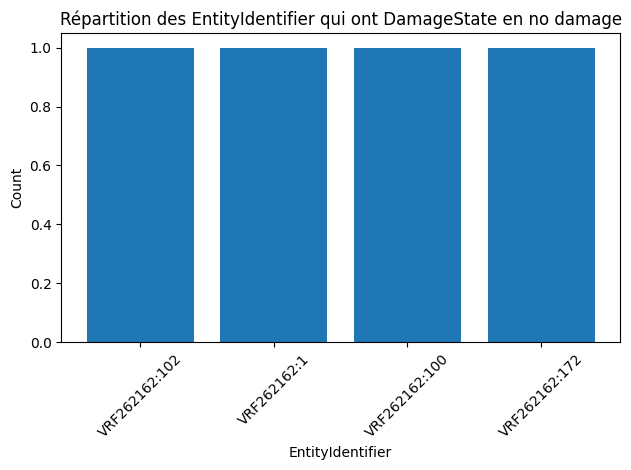


Graph sauvegardé dans: out13.png


In [13]:

# Cas legacy (doit rester stable)
run_llm_visualizer(
     file="data/lidata.log",
     prompt="Répartition des EntityIdentifier qui ont DamageState en no damage",
     out="out13.png"
 )



INTENTION DETECTEE (safe):
 {'intent': 'table', 'chart': 'bar', 'aggregation': None, 'group_by': 'EntityIdentifier', 'x': 'HasAmmunitionSupplyCap', 'y': None, 'top_n': None, 'bins': None, 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}]}

DEBUG INTENTION (raw/received): {'intent': 'table', 'chart': 'bar', 'aggregation': None, 'group_by': 'EntityIdentifier', 'x': 'HasAmmunitionSupplyCap', 'y': None, 'top_n': None, 'bins': None, 'filter': [{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}]}
[debug] PlotSpec: PlotSpec(plot_type='bar_agg', x='HasAmmunitionSupplyCap', y=None, group_by='EntityIdentifier', filters=[{'column': 'HasAmmunitionSupplyCap', 'value': False, 'op': '=='}], sort_by='value', sort_ascending=False, aggregation='count', top_n=None, bins=None)


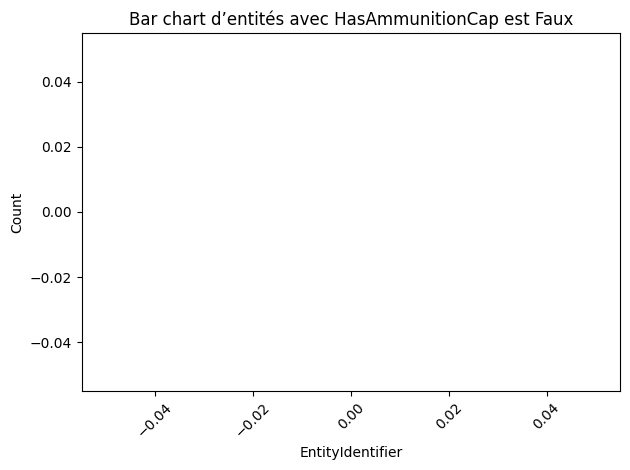


Graph sauvegardé dans: out.png


In [14]:
run_llm_visualizer(
    file="data/lidata.log",
    prompt="Bar chart d’entités avec HasAmmunitionCap est Faux",
    out="out.png"
)

In [ ]:

# Nouveaux cas
# run_llm_visualizer(
#     file="data/lidata.log",
#     prompt="Pie chart des entités par ForceIdentifier",
#     out="pie_force.png"
# )

# run_llm_visualizer(
#     file="data/lidata.log",
#     prompt="Histogramme de SimTime",
#     out="hist_simtime.png"
# )

# run_llm_visualizer(
#     file="data/lidata.log",
#     prompt="Moyenne de Spatial_FPB_WorldLocation_x par ForceIdentifier",
#     out="mean_x_by_force.png"
# )

# run_llm_visualizer(
#     file="data/lidata.log",
#     prompt="Metric du nombre d'entités",
#     out="metric_count.png"
# )

# run_llm_visualizer(
#     file="data/lidata.log",
#     prompt="Table du nombre d'entités par EntityType",
#     out="table_entitytype.png"
# )